# **Rossmann Store Sales Forecasting — EDA**

## Step 1. Business Understanding

### Business Problem
Rossmann Pharmaceuticals operates multiple retail stores across different locations. Store managers currently rely on their experience and personal judgment to estimate future sales. The business wants a data-driven approach to forecast daily store sales up to six weeks in advance.

The dataset contains factors such as promotions, holidays, seasonality, store characteristics, customers, and competition that may influence sales.

### Project Objective
The main objective of this project is to explore customer purchasing behaviour and build a sales forecasting solution that can predict daily sales for Rossmann stores.

The EDA will focus on understanding how factors such as promotions, holidays, customers, store characteristics, seasonality, and competition affect sales.

### Understanding the Dataset
The project provides four CSV files:

*   train.csv — historical store-level daily data containing the Sales target.
*   test.csv — store/date records for which sales need to be predicted.
*   store.csv — additional information describing each store.
*   sample_submission.csv — reference format for the final prediction submission.

The main target variable is Sales, which represents the turnover generated by a store on a given day.

## Step 2. Import Required Libraries




### Python Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# File and system handling
import os

### Visualization Libraries

In [2]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

### Logging Configuration

In [3]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True
)

logger = logging.getLogger(__name__)

logger.info("Libraries imported and logging configured successfully.")

2026-09-13 16:23:05,760 - INFO - Libraries imported and logging configured successfully.


## Step 3. Load the Datasets

### Load train.csv

In [4]:
train_df = pd.read_csv("../data/train.csv")

logger.info("Train dataset loaded successfully.")

C:\Users\akanksha\AppData\Local\Temp\ipykernel_29224\2674998936.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("../data/train.csv")
2026-09-13 16:23:06,692 - INFO - Train dataset loaded successfully.


### Load test.csv

In [5]:
test_df = pd.read_csv("../data/test.csv")

logger.info("Test dataset loaded successfully.")

2026-09-13 16:23:06,745 - INFO - Test dataset loaded successfully.


### Load store.csv

In [6]:
store_df = pd.read_csv("../data/store.csv")

logger.info("Store dataset loaded successfully.")

2026-09-13 16:23:06,760 - INFO - Store dataset loaded successfully.


### Load sample_submission.csv

In [7]:
sample_submission_df = pd.read_csv("../data/sample_submission.csv")

logger.info("Sample submission dataset loaded successfully.")

2026-09-13 16:23:06,780 - INFO - Sample submission dataset loaded successfully.


## Step 4. Initial Data Understanding

### Dataset Shape

Before beginning the detailed analysis, we examine the size of each dataset to understand the number of records and features available.

In [8]:
# Display the shape of each dataset
print("Train Dataset Shape:", train_df.shape)
print("Test Dataset Shape:", test_df.shape)
print("Store Dataset Shape:", store_df.shape)
print("Sample Submission Shape:", sample_submission_df.shape)

Train Dataset Shape: (1017209, 9)
Test Dataset Shape: (41088, 8)
Store Dataset Shape: (1115, 10)
Sample Submission Shape: (41088, 2)


### Dataset Head
We inspect the first few records of each dataset to understand its structure, the available variables, and how the data is represented.

In [9]:
# Display the first 5 rows of each dataset
print("Train Dataset:")
display(train_df.head())

print("Test Dataset:")
display(test_df.head())

print("Store Dataset:")
display(store_df.head())

print("Sample Submission:")
display(sample_submission_df.head())

Train Dataset:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


Test Dataset:


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


Store Dataset:


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


Sample Submission:


,Id,Sales
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


### Dataset Information
We examine the dataset structure, data types, and non-null counts to identify potential data-quality issues that may need to be addressed before analysis.

In [10]:
print("Train Dataset Information:")
train_df.info()

print("\nTest Dataset Information:")
test_df.info()

print("\nStore Dataset Information:")
store_df.info()

print("\nSample Submission Information:")
sample_submission_df.info()

Train Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 79.5+ MB

Test Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             41088 non-null  int64  
 1   Store          41088 non-null  int64  
 2   DayOfWeek    

### Statistical Summary
We review the statistical summary of the numerical variables to understand their ranges, central tendencies, and variability and to identify values that may require further investigation.

In [11]:
# Statistical summary of numerical columns

print("Train Dataset - Statistical Summary")
display(train_df.describe())

print("Test Dataset - Statistical Summary")
display(test_df.describe())

print("Store Dataset - Statistical Summary")
display(store_df.describe())

print("Sample Submission - Statistical Summary")
display(sample_submission_df.describe())

Train Dataset - Statistical Summary


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


Test Dataset - Statistical Summary


,Id,Store,DayOfWeek,Open,Promo,SchoolHoliday
count,41088.000000,41088.000000,41088.000000,41077.000000,41088.000000,41088.000000
mean,20544.500000,555.899533,3.979167,0.854322,0.395833,0.443487
std,11861.228267,320.274496,2.015481,0.352787,0.489035,0.496802
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,10272.750000,279.750000,2.000000,1.000000,0.000000,0.000000
50%,20544.500000,553.500000,4.000000,1.000000,0.000000,0.000000
75%,30816.250000,832.250000,6.000000,1.000000,1.000000,1.000000
max,41088.000000,1115.000000,7.000000,1.000000,1.000000,1.000000


Store Dataset - Statistical Summary


,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


Sample Submission - Statistical Summary


,Id,Sales
count,41088.000000,41088.0
mean,20544.500000,0.0
std,11861.228267,0.0
min,1.000000,0.0
25%,10272.750000,0.0
50%,20544.500000,0.0
75%,30816.250000,0.0
max,41088.000000,0.0


## Step 5. Data Quality Analysis

### Missing Values

Before performing exploratory analysis, it is important to identify missing values in the datasets. Missing data can affect statistical analysis, visualizations, and model performance, so these values will be investigated and handled appropriately during the data preparation stage.

In [12]:
# Check missing values in all datasets

print("Train Dataset - Missing Values")
display(train_df.isnull().sum())

print("Test Dataset - Missing Values")
display(test_df.isnull().sum())

print("Store Dataset - Missing Values")
display(store_df.isnull().sum())

print("Sample Submission - Missing Values")
display(sample_submission_df.isnull().sum())

Train Dataset - Missing Values


Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

Test Dataset - Missing Values


Id                0
Store             0
DayOfWeek         0
Date              0
Open             11
Promo             0
StateHoliday      0
SchoolHoliday     0
dtype: int64

Store Dataset - Missing Values


Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

Sample Submission - Missing Values


Id       0
Sales    0
dtype: int64

Observation

*  Train: No missing values are present in any column. All variables have 0 missing values.
*  Test: 11 missing values are present in Open.
*  Store: missing values are mainly present in competition-related and Promo2-related columns.
* Sample Submission: no missing values are present.



### Duplicate Records
Duplicate records can cause observations to be counted more than once and may distort the results of exploratory analysis and model training. Therefore, we check each dataset for completely duplicated rows before proceeding further.

In [13]:
# Check duplicate records in all datasets

print("Train Dataset - Duplicate Rows:", train_df.duplicated().sum())
print("Test Dataset - Duplicate Rows:", test_df.duplicated().sum())
print("Store Dataset - Duplicate Rows:", store_df.duplicated().sum())
print("Sample Submission - Duplicate Rows:", sample_submission_df.duplicated().sum())

Train Dataset - Duplicate Rows: 0
Test Dataset - Duplicate Rows: 0
Store Dataset - Duplicate Rows: 0
Sample Submission - Duplicate Rows: 0


Observation
* Train dataset: 0 duplicates
* Test dataset: 0 duplicates
* Store dataset: 0 duplicates
* Sample submission: 0 duplicates

### Validity and Consistency Checks
After checking missing and duplicate records, we verify whether the datasets contain inconsistent or invalid values. This helps ensure that categorical fields, binary indicators, dates, and numerical variables follow their expected formats and ranges before further analysis.

In [14]:
# Check unique values in categorical and binary columns

print("Train - DayOfWeek:", sorted(train_df["DayOfWeek"].dropna().unique()))
print("Train - Open:", sorted(train_df["Open"].dropna().unique()))
print("Train - Promo:", sorted(train_df["Promo"].dropna().unique()))
print("Train - StateHoliday:", train_df["StateHoliday"].dropna().unique())
print("Train - SchoolHoliday:", sorted(train_df["SchoolHoliday"].dropna().unique()))

print("\nTest - DayOfWeek:", sorted(test_df["DayOfWeek"].dropna().unique()))
print("Test - Open:", sorted(test_df["Open"].dropna().unique()))
print("Test - Promo:", sorted(test_df["Promo"].dropna().unique()))
print("Test - StateHoliday:", test_df["StateHoliday"].dropna().unique())
print("Test - SchoolHoliday:", sorted(test_df["SchoolHoliday"].dropna().unique()))

print("\nStore - StoreType:", store_df["StoreType"].unique())
print("Store - Assortment:", store_df["Assortment"].unique())
print("Store - Promo2:", sorted(store_df["Promo2"].unique()))

Train - DayOfWeek: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Train - Open: [np.int64(0), np.int64(1)]
Train - Promo: [np.int64(0), np.int64(1)]
Train - StateHoliday: ['0' 'a' 'b' 'c' 0]
Train - SchoolHoliday: [np.int64(0), np.int64(1)]

Test - DayOfWeek: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Test - Open: [np.float64(0.0), np.float64(1.0)]
Test - Promo: [np.int64(0), np.int64(1)]
Test - StateHoliday: <ArrowStringArray>
['0', 'a']
Length: 2, dtype: str
Test - SchoolHoliday: [np.int64(0), np.int64(1)]

Store - StoreType: <ArrowStringArray>
['c', 'a', 'd', 'b']
Length: 4, dtype: str
Store - Assortment: <ArrowStringArray>
['a', 'c', 'b']
Length: 3, dtype: str
Store - Promo2: [np.int64(0), np.int64(1)]


Observation
* DayOfWeek: values are correctly in the range 1–7.
* Open: contains 0.0 and 1.0, which are the expected binary values. They are floats, but there is no issue simply because they are written as 0.0 and 1.0.
* Promo: contains 0.0 and 1.0 in train and 0 and 1 in test. These represent the same binary values; the difference is only the numeric type/representation.
* SchoolHoliday: contains 0.0 and 1.0 in train and 0 and 1 in test. Again, these represent the same binary values.
* Promo2: contains 0 and 1, as expected.
* StoreType: contains a, b, c, d, which are expected categories.
* Assortment: contains a, b, c, which are expected categories.
* StateHoliday: this is the actual inconsistent representation in the train data because it contains both '0' (string) and 0.0 (float). These should logically represent the same "no state holiday" category, but they have different types.



### Unique Values
We examine the unique values in each column to understand the structure and variety of the data. This helps identify categorical and binary variables, understand their possible categories, verify that expected values are present, and detect unexpected or inconsistent values before performing EDA and encoding.

In [15]:
# Check number of unique values in each dataset

print("Train Dataset - Unique Values")
display(train_df.nunique())

print("Test Dataset - Unique Values")
display(test_df.nunique())

print("Store Dataset - Unique Values")
display(store_df.nunique())

print("Sample Submission - Unique Values")
display(sample_submission_df.nunique())

Train Dataset - Unique Values


Store             1115
DayOfWeek            7
Date               942
Sales            21734
Customers         4086
Open                 2
Promo                2
StateHoliday         5
SchoolHoliday        2
dtype: int64

Test Dataset - Unique Values


Id               41088
Store              856
DayOfWeek            7
Date                48
Open                 2
Promo                2
StateHoliday         2
SchoolHoliday        2
dtype: int64

Store Dataset - Unique Values


Store                        1115
StoreType                       4
Assortment                      3
CompetitionDistance           654
CompetitionOpenSinceMonth      12
CompetitionOpenSinceYear       23
Promo2                          2
Promo2SinceWeek                24
Promo2SinceYear                 7
PromoInterval                   3
dtype: int64

Sample Submission - Unique Values


Id       41088
Sales        1
dtype: int64

Observation
* Store has 1,115 unique stores in the train and store datasets.
* DayOfWeek has 7 unique values, representing the days of the week.
* Binary variables such as Open, Promo, SchoolHoliday, and Promo2 have 2 unique values.
* StoreType has 4 categories, while Assortment has 3 categories.
* StateHoliday has 5 unique values in train and 2 in test, which will need attention during preprocessing.
* Test contains 48 unique dates, while train contains 320 unique dates.

### Outlier Detection
For outlier detection, we focus on the key continuous numerical variables, Sales and Customers, because unusually high or low values in these variables may represent extreme business observations and can influence analysis and modeling. Identifier columns, binary indicators, categorical variables, and date-related fields are excluded because applying a standard IQR outlier method to them would not be meaningful.

In [16]:
# Select important numerical columns for outlier detection

outlier_columns = [
    "Sales",
    "Customers"
]

# Calculate IQR-based outlier counts
for column in outlier_columns:
    Q1 = train_df[column].quantile(0.25)
    Q3 = train_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = train_df[
        (train_df[column] < lower_bound) |
        (train_df[column] > upper_bound)
    ][column].count()

    print(f"{column}:")
    print(f"Lower Bound = {lower_bound:.2f}")
    print(f"Upper Bound = {upper_bound:.2f}")
    print(f"Number of Outliers = {outliers}")
    print()

Sales:
Lower Bound = -2466.50
Upper Bound = 14049.50
Number of Outliers = 26694

Customers:
Lower Bound = -243.00
Upper Bound = 1485.00
Number of Outliers = 38095



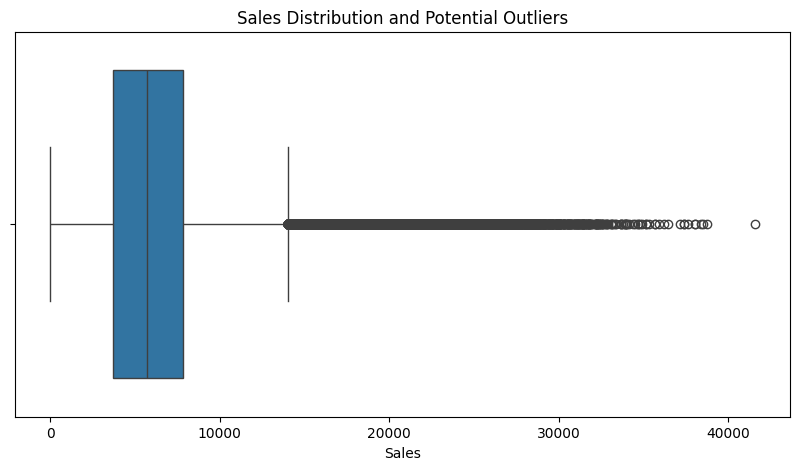

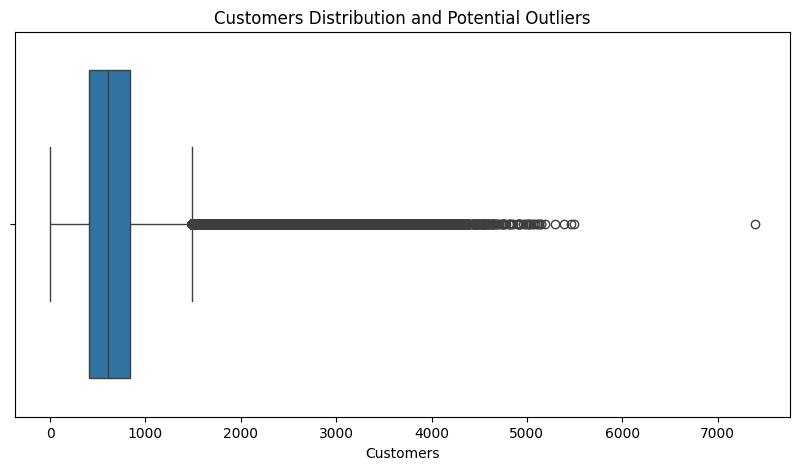

In [17]:
# Visualize potential outliers in Sales and Customers

plt.figure(figsize=(10, 5))
sns.boxplot(x=train_df["Sales"])
plt.title("Sales Distribution and Potential Outliers")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=train_df["Customers"])
plt.title("Customers Distribution and Potential Outliers")
plt.show()

##Step 6. Data Preparation for EDA
Before performing detailed exploratory analysis, the datasets need to be prepared into a consistent and analysis-ready format. This includes combining the store-level information with the respective train and test records and creating useful date-based features for temporal analysis.

### Merge Train Data with Store Data
train.csv contains daily sales information, while store.csv contains additional characteristics such as StoreType, Assortment, CompetitionDistance, and Promo2. Merging them allows us to analyze how these store-level factors relate to sales.

In [18]:
# Merge train data with store data using Store as the common key

train_merged = train_df.merge(
    store_df,
    on="Store",
    how="left"
)

logger.info("Train and store datasets merged successfully.")
print("Merged Train Dataset Shape:", train_merged.shape)

2026-09-13 16:23:09,565 - INFO - Train and store datasets merged successfully.


Merged Train Dataset Shape: (1017209, 18)


### Merge Test Data with Store Data
test.csv contains the store and date information required for future sales prediction, while store.csv provides additional characteristics for each store. Merging them allows us to retain these store-level features for the test records without combining the training and test datasets.

In [19]:
# Merge test data with store data using Store as the common key

test_merged = test_df.merge(
    store_df,
    on="Store",
    how="left"
)

logger.info("Test and store datasets merged successfully.")
print("Merged Test Dataset Shape:", test_merged.shape)

2026-09-13 16:23:09,586 - INFO - Test and store datasets merged successfully.


Merged Test Dataset Shape: (41088, 17)


### Convert Date to Datetime
The Date column is currently stored as text. Converting it to datetime format allows us to perform time-based analysis and extract useful features such as year, month, week, day, and weekday.

In [20]:
# Convert Date column to datetime format

train_merged["Date"] = pd.to_datetime(train_merged["Date"])
test_merged["Date"] = pd.to_datetime(test_merged["Date"])

logger.info("Date columns converted to datetime successfully.")

print("Train Date dtype:", train_merged["Date"].dtype)
print("Test Date dtype:", test_merged["Date"].dtype)

2026-09-13 16:23:09,767 - INFO - Date columns converted to datetime successfully.


Train Date dtype: datetime64[us]
Test Date dtype: datetime64[us]


### Create Date-Based Features
Date-based features help us understand how sales behaviour changes over time. We extract the year, month, week, day, weekday, and a weekend indicator so these temporal patterns can be explored during EDA and used as meaningful features for forecasting.

In [21]:
# Create date-based features for train and test datasets

for df in [train_merged, test_merged]:
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
    df["Day"] = df["Date"].dt.day
    df["Weekday"] = df["Date"].dt.weekday
    df["IsWeekend"] = (df["Weekday"] >= 5).astype(int)

logger.info("Date-based features created successfully.")

print("Train dataset columns after feature creation:")
print(train_merged.columns.tolist())

print("\nTest dataset columns after feature creation:")
print(test_merged.columns.tolist())

2026-09-13 16:23:09,902 - INFO - Date-based features created successfully.


Train dataset columns after feature creation:
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Week', 'Day', 'Weekday', 'IsWeekend']

Test dataset columns after feature creation:
['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Week', 'Day', 'Weekday', 'IsWeekend']


## Step 7. Exploratory Data Analysis

### Univariate Analysis
Univariate analysis examines each variable individually to understand its distribution and overall behaviour. This helps us identify common patterns in sales, customers, promotions, store operations, holidays, store characteristics, and competition before studying relationships between variables.

#### Numerical Variables
We first examine the distribution of the main numerical variables to understand their typical ranges, concentration, and overall patterns.

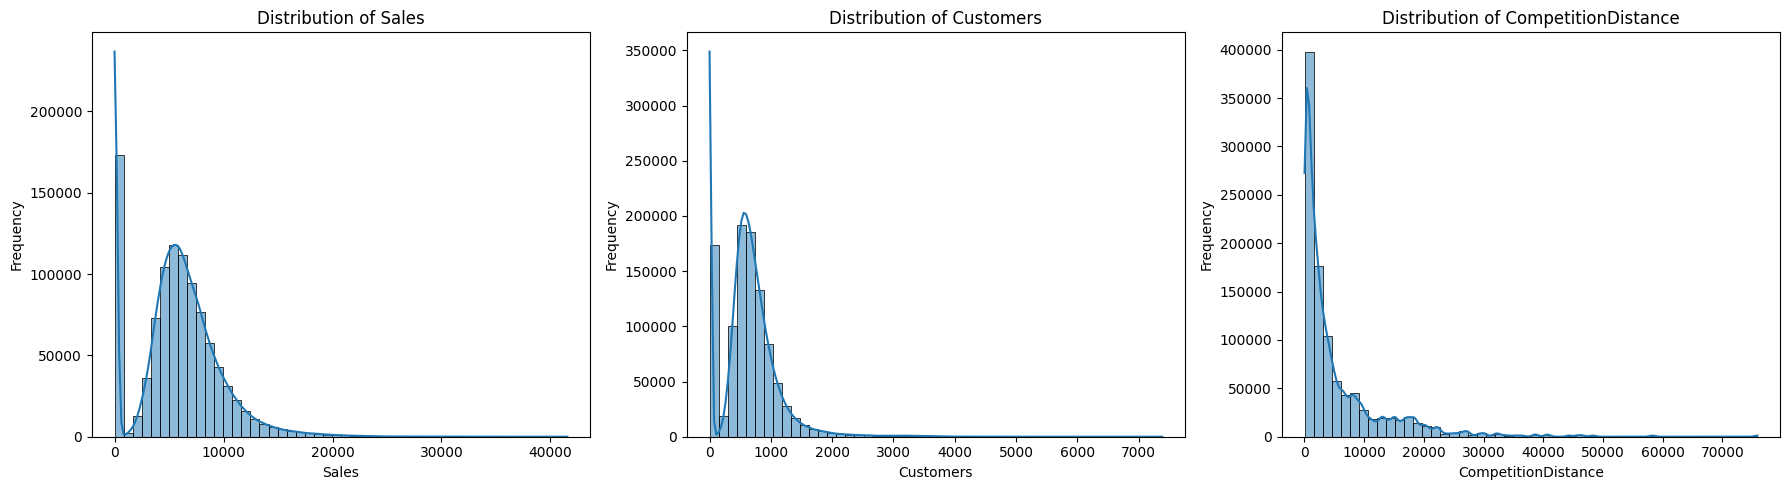

In [22]:
numerical_columns = [
    "Sales",
    "Customers",
    "CompetitionDistance"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, column in enumerate(numerical_columns):
    sns.histplot(
        train_merged[column].dropna(),
        bins=50,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Categorical Variables
Next, we examine the frequency of categorical and binary variables to understand how observations are distributed across promotions, store operations, holidays, store types, and assortment types.


2026-09-13 16:23:20,096 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-13 16:23:20,314 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-13 16:23:20,697 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-13 16:23:20,920 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


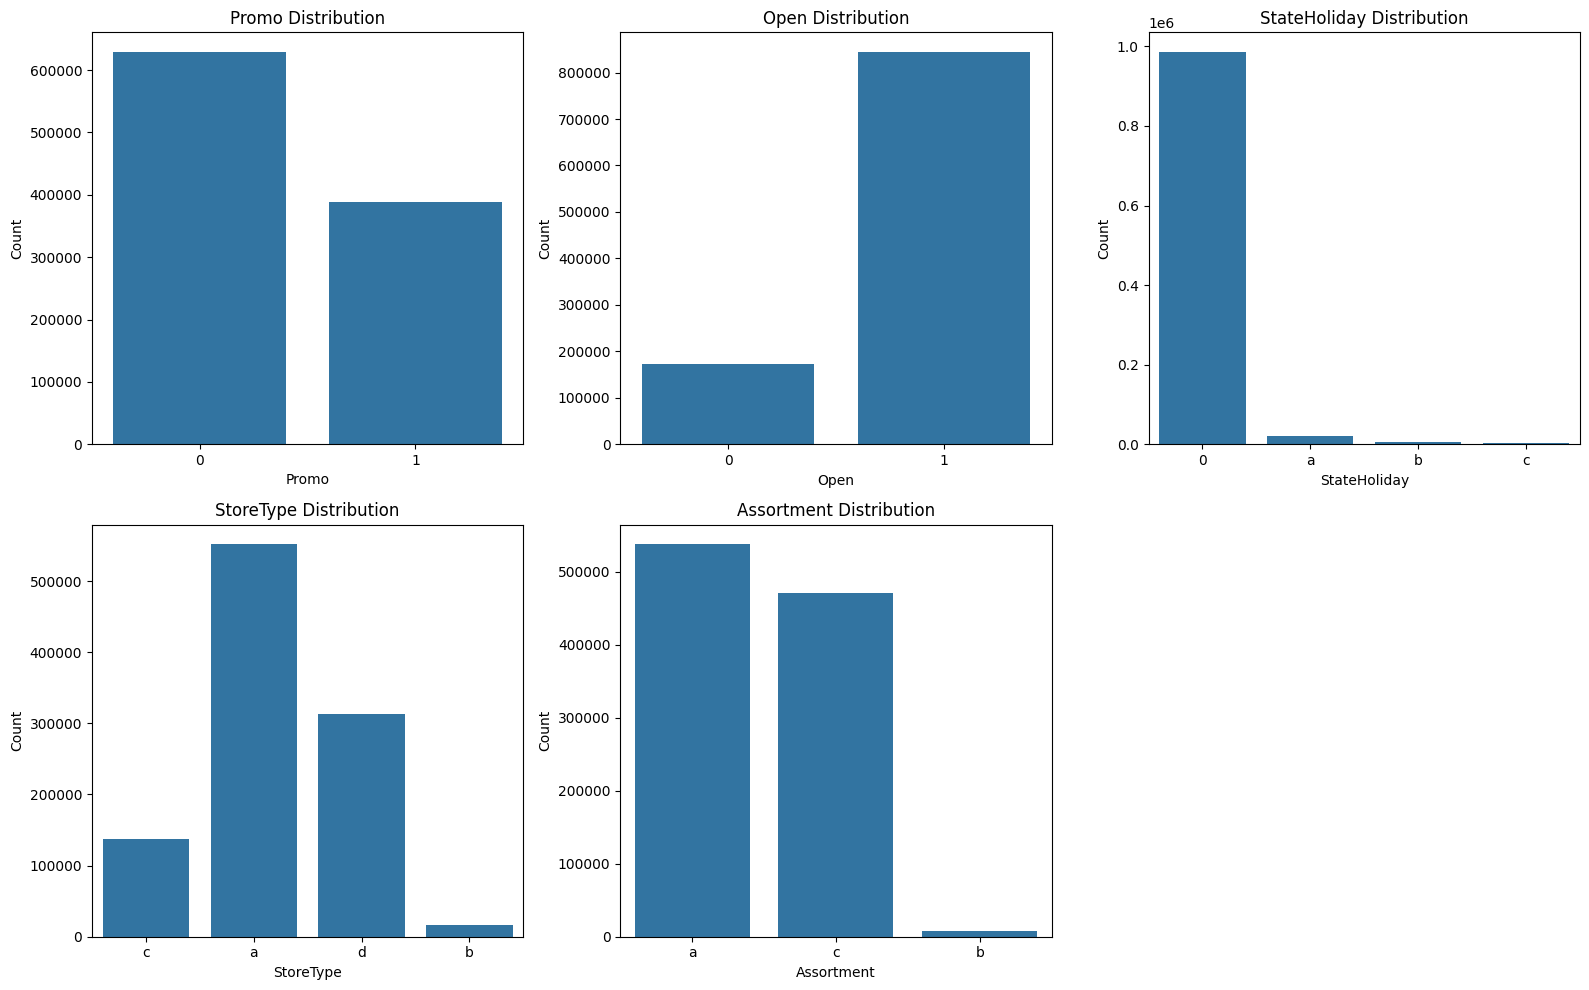

In [23]:
categorical_columns = [
    "Promo",
    "Open",
    "StateHoliday",
    "StoreType",
    "Assortment"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, column in enumerate(categorical_columns):
    sns.countplot(
        data=train_merged,
        x=column,
        ax=axes[i]
    )
    axes[i].set_title(f"{column} Distribution")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Count")

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

Observation
* Sales and Customers are right-skewed, with most observations concentrated at lower-to-moderate values and a smaller number of very high values.
* CompetitionDistance is highly right-skewed, with most stores having relatively shorter competition distances and fewer stores having very large distances.
* Promotions are present on a substantial portion of store-days, but non-promotion days are more frequent.
* Most records correspond to open stores, while closed-store records form a smaller portion.
* State holidays are relatively rare compared with regular days.
* StoreType A is the most common store type, while StoreType B is the least common.
* Assortment A and C account for most observations, while Assortment B is comparatively rare.

### Bivariate Analysis
After understanding individual variable distributions, we now examine relationships between variables. This helps us understand how customer activity, promotions, holidays, store operations, store characteristics, and competition are associated with sales.

#### Customer and Promotion Relationships

2026-09-13 16:23:23,436 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-13 16:23:23,655 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-13 16:23:24,089 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-13 16:23:24,307 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


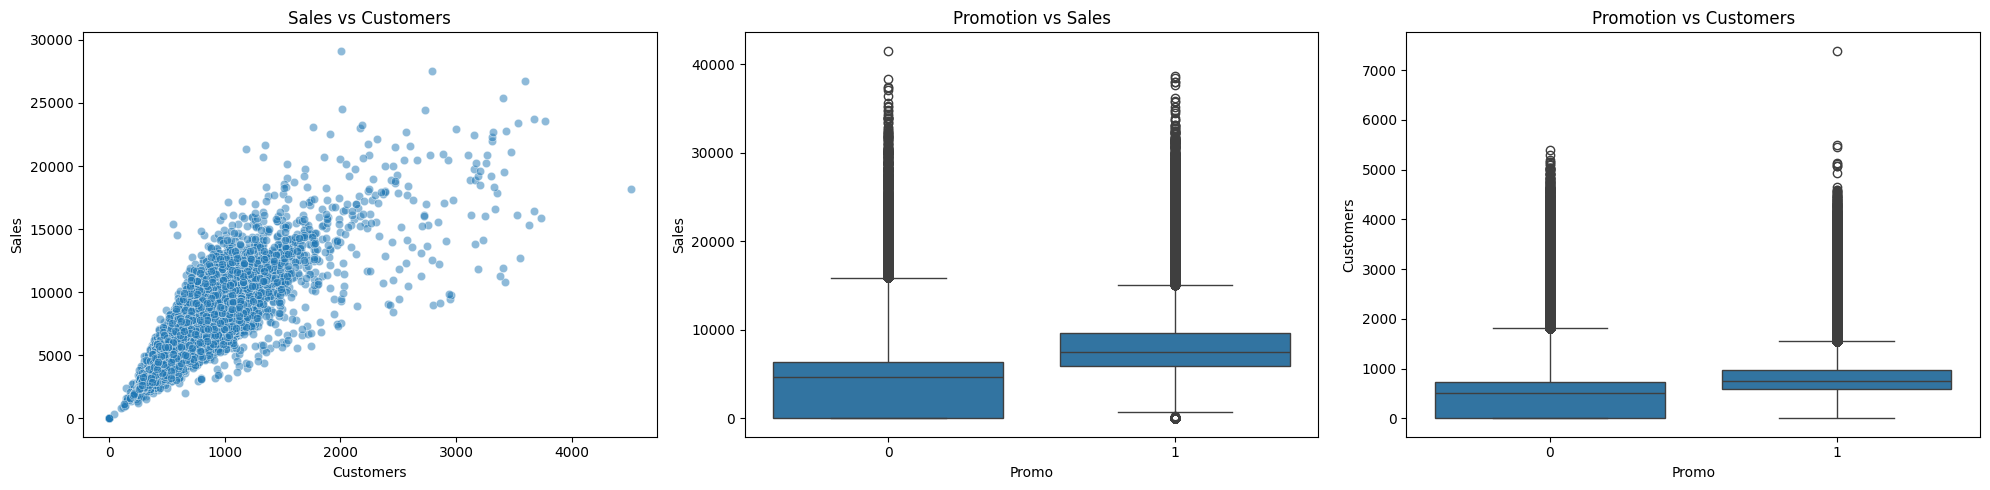

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Sales vs Customers
sns.scatterplot(
    data=train_merged.sample(10000, random_state=42),
    x="Customers",
    y="Sales",
    ax=axes[0],
    alpha=0.5
)
axes[0].set_title("Sales vs Customers")

# Promotion vs Sales
sns.boxplot(
    data=train_merged,
    x="Promo",
    y="Sales",
    ax=axes[1]
)
axes[1].set_title("Promotion vs Sales")

# Promotion vs Customers
sns.boxplot(
    data=train_merged,
    x="Promo",
    y="Customers",
    ax=axes[2]
)
axes[2].set_title("Promotion vs Customers")

plt.tight_layout()
plt.show()

Observation
* Sales show a clear positive relationship with Customers; stores with more customers generally generate higher sales.
* Promotional days show higher sales levels than non-promotion days, indicating that promotions are associated with increased sales.
* Customer counts are also generally higher during promotional periods, suggesting that promotions can attract more customers.
* There are several high-value observations in both groups, which is consistent with the outlier patterns identified earlier.

#### Holiday, Store Operation and Store Characteristics vs Sales
We now compare sales across holidays, store operating status, weekday, and assortment type. These comparisons help identify whether sales behaviour differs according to store operations, calendar conditions, and store characteristics.

2026-09-13 16:23:25,780 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-13 16:23:26,000 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-13 16:23:26,422 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-13 16:23:26,641 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


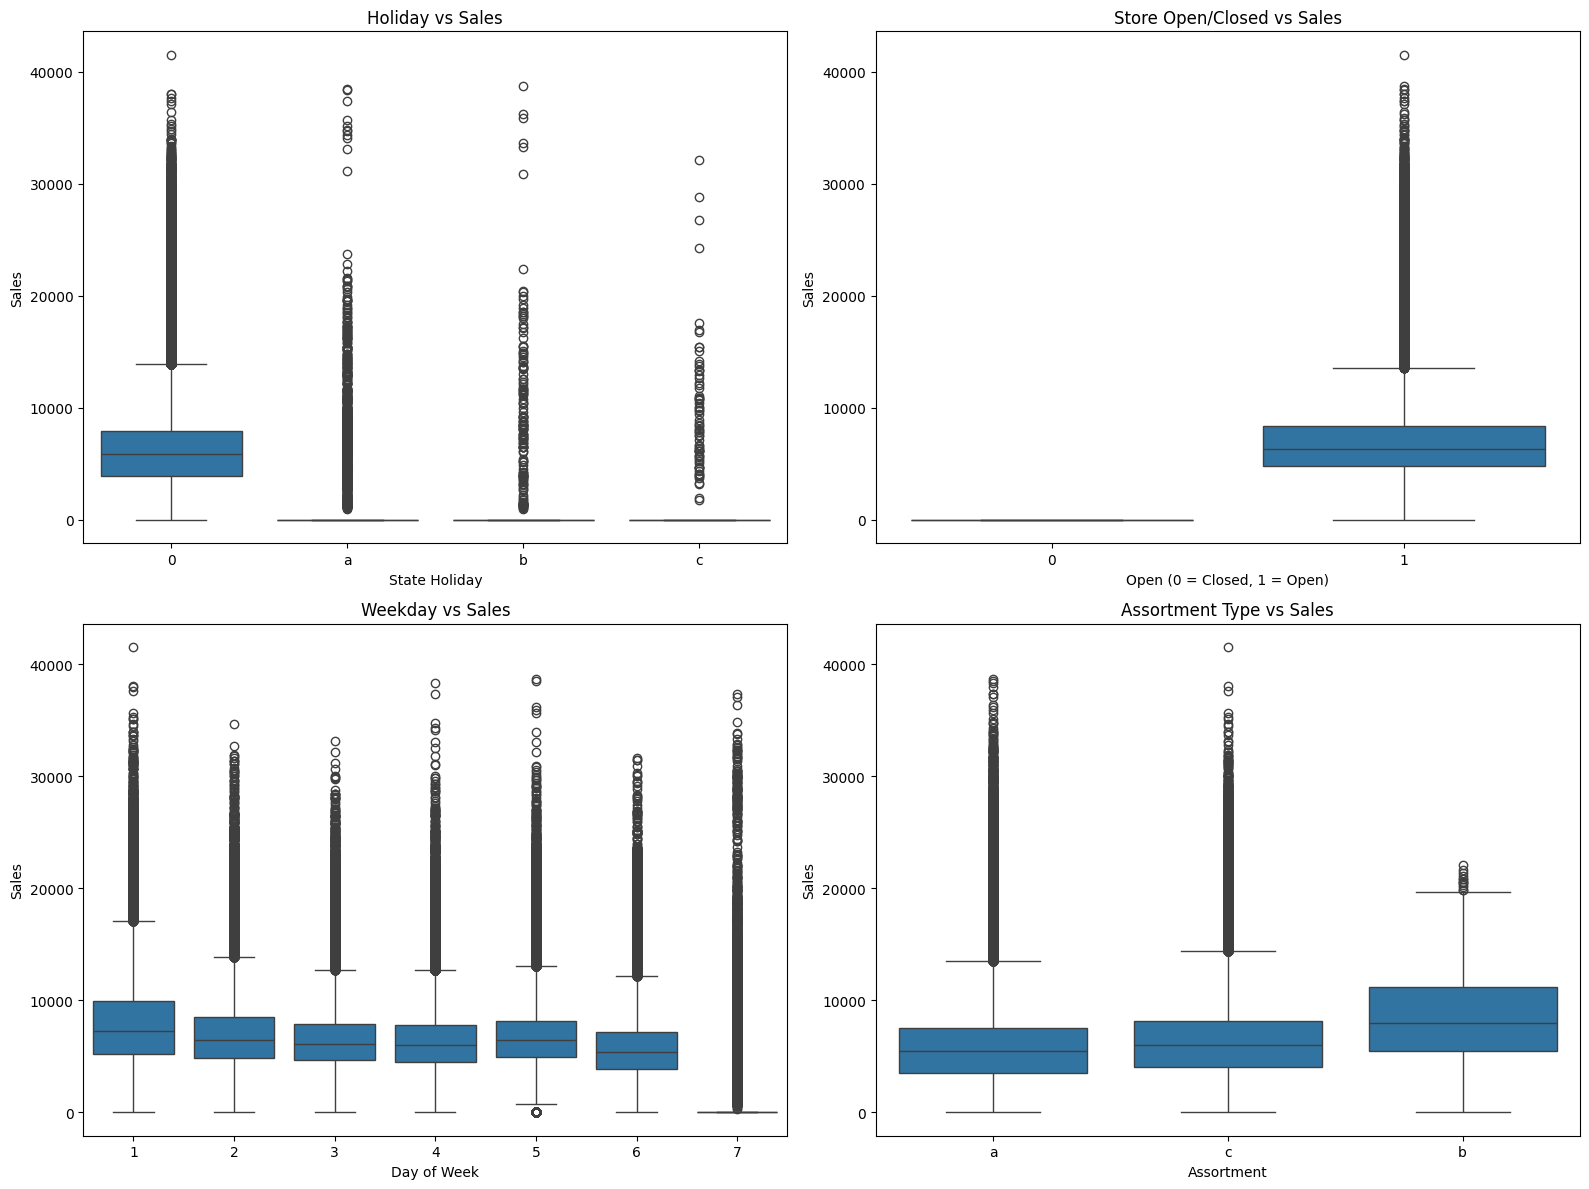

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Holiday vs Sales
sns.boxplot(
    data=train_merged,
    x="StateHoliday",
    y="Sales",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Holiday vs Sales")
axes[0, 0].set_xlabel("State Holiday")
axes[0, 0].set_ylabel("Sales")

# Store Open/Closed vs Sales
sns.boxplot(
    data=train_merged,
    x="Open",
    y="Sales",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Store Open/Closed vs Sales")
axes[0, 1].set_xlabel("Open (0 = Closed, 1 = Open)")
axes[0, 1].set_ylabel("Sales")

# Weekday vs Sales
sns.boxplot(
    data=train_merged,
    x="DayOfWeek",
    y="Sales",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Weekday vs Sales")
axes[1, 0].set_xlabel("Day of Week")
axes[1, 0].set_ylabel("Sales")

# Assortment vs Sales
sns.boxplot(
    data=train_merged,
    x="Assortment",
    y="Sales",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Assortment Type vs Sales")
axes[1, 1].set_xlabel("Assortment")
axes[1, 1].set_ylabel("Sales")

plt.tight_layout()
plt.show()

#### Competition Distance vs Sales
Finally, we examine whether the distance to the nearest competitor is associated with store sales. This helps us understand whether competitive proximity may influence store performance.

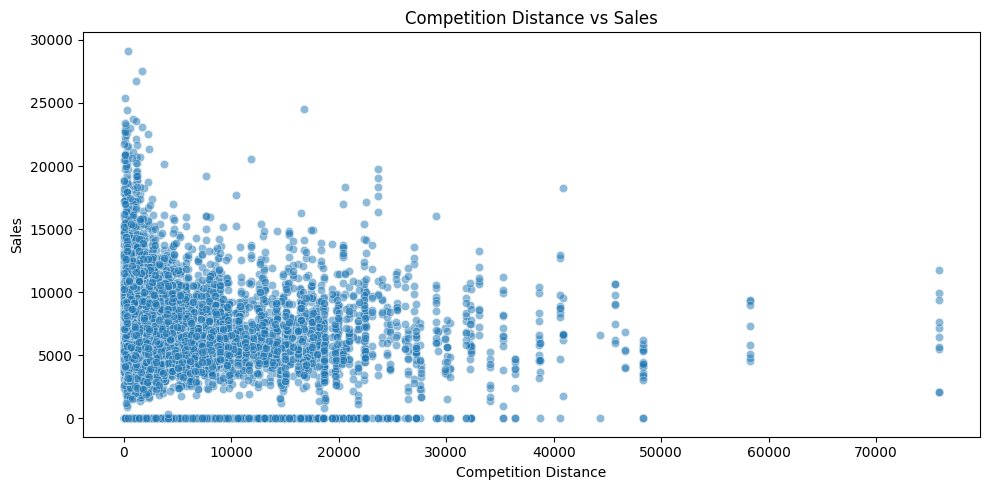

In [26]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=train_merged.sample(10000, random_state=42),
    x="CompetitionDistance",
    y="Sales",
    alpha=0.5
)

plt.title("Competition Distance vs Sales")
plt.xlabel("Competition Distance")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

Observation — Holiday, Store Operations and Competition
* Open/Closed vs Sales: Open stores generate sales, while closed stores have zero sales, showing that store operating status is a direct factor in sales.
* Holiday vs Sales: Sales are much lower on state holidays, with many zero-sales observations due to stores being closed; holiday effects should therefore be considered together with store operating status.
* Weekday vs Sales: Sales vary across the days of the week, with Sunday (Day 7) showing the lowest sales because many stores are closed, while the other weekdays show higher sales levels.
* Assortment vs Sales: Stores with Assortment B show higher typical sales, while Assortment A has the lowest median sales among the three types.
* Competition Distance vs Sales: The scatterplot does not show a strong clear linear relationship between competition distance and sales. Sales vary considerably at different competition distances.

### Time-Series / Temporal Analysis

#### Temporal Sales Trends
Sales can change over time because of seasonality, yearly patterns, and monthly variations. We therefore examine daily, monthly, and yearly sales trends to identify recurring temporal behaviour that may be useful for forecasting.

2026-09-13 16:23:27,969 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-13 16:23:27,973 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


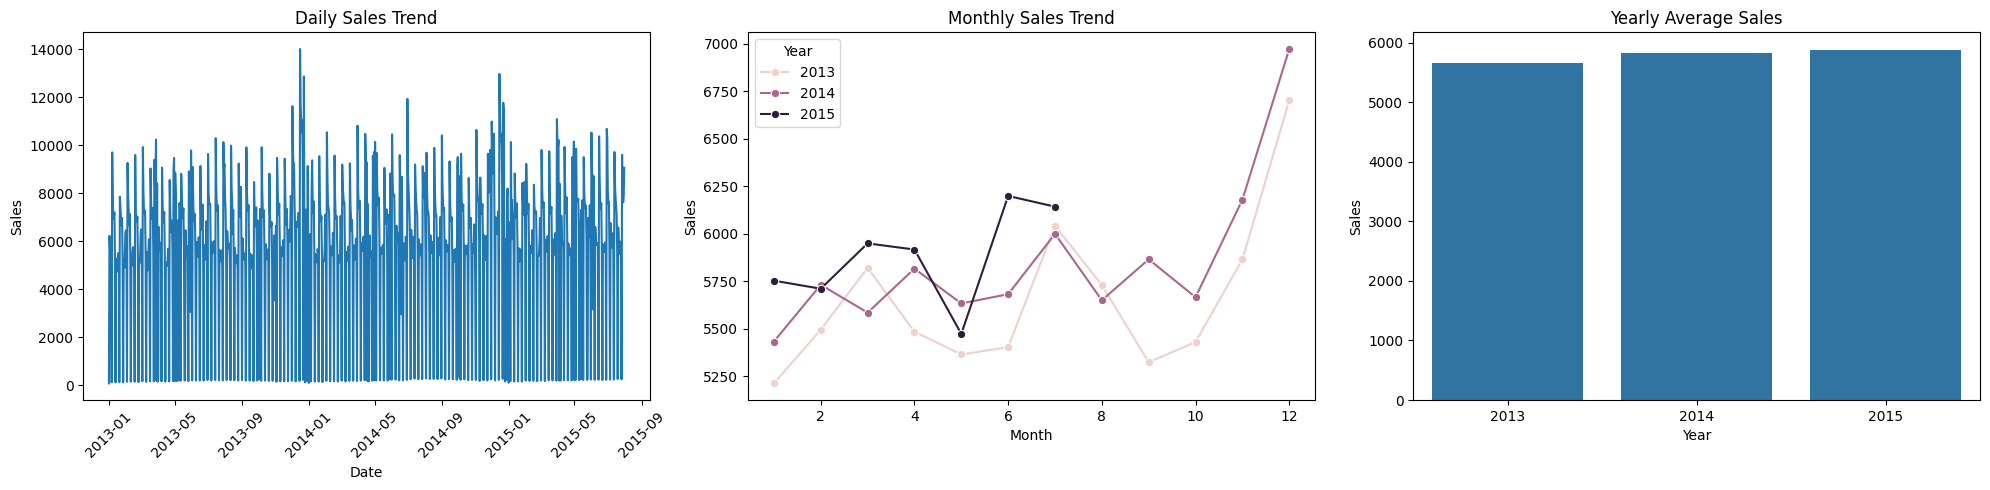

In [27]:
# Prepare daily, monthly and yearly sales

daily_sales = (
    train_merged
    .groupby("Date")["Sales"]
    .mean()
    .reset_index()
)

monthly_sales = (
    train_merged
    .groupby(["Year", "Month"])["Sales"]
    .mean()
    .reset_index()
)

yearly_sales = (
    train_merged
    .groupby("Year")["Sales"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Daily Sales Trend
sns.lineplot(
    data=daily_sales,
    x="Date",
    y="Sales",
    ax=axes[0]
)
axes[0].set_title("Daily Sales Trend")
axes[0].tick_params(axis="x", rotation=45)

# Monthly Sales Trend
sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Monthly Sales Trend")

# Yearly Sales Trend
sns.barplot(
    data=yearly_sales,
    x="Year",
    y="Sales",
    ax=axes[2]
)
axes[2].set_title("Yearly Average Sales")

plt.tight_layout()
plt.show()

Observation
* Daily sales show strong fluctuations over time, with recurring peaks and lower-sales periods, indicating that sales behaviour is not constant across days.
* Monthly sales show a recurring seasonal pattern, with higher average sales toward the end of the year, particularly in November–December, while several mid-year months show comparatively lower sales.
* Average yearly sales increase gradually from 2013 to 2015, indicating an overall upward trend in store sales across the observed years.
* The observed yearly and monthly patterns indicate temporal and seasonal effects, which should be captured through date-based features during forecasting.

#### Weekday/Weekend and Promotion Behaviour
We further examine weekly purchasing behaviour and promotional activity to understand whether sales and promotions follow consistent patterns across weekdays and over time.

2026-09-13 16:23:28,514 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-13 16:23:28,737 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


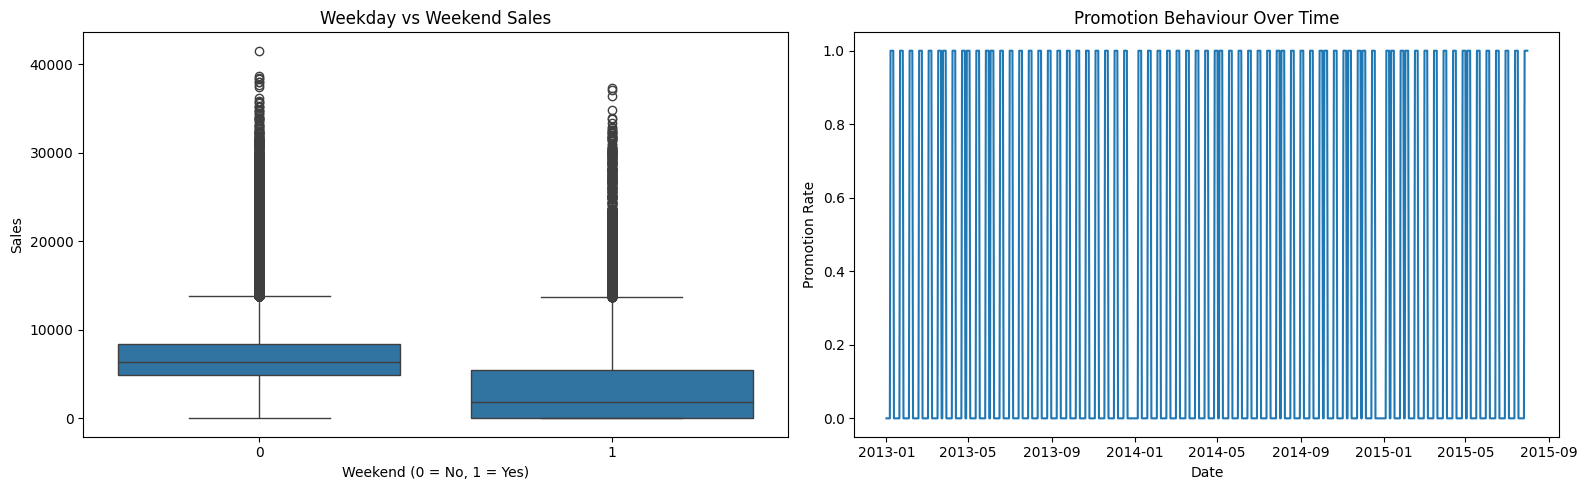

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Weekday vs Weekend Sales
sns.boxplot(
    data=train_merged,
    x="IsWeekend",
    y="Sales",
    ax=axes[0]
)
axes[0].set_title("Weekday vs Weekend Sales")
axes[0].set_xlabel("Weekend (0 = No, 1 = Yes)")
axes[0].set_ylabel("Sales")

# Promotion Behaviour Over Time
promo_over_time = (
    train_merged
    .groupby("Date")["Promo"]
    .mean()
    .reset_index()
)

sns.lineplot(
    data=promo_over_time,
    x="Date",
    y="Promo",
    ax=axes[1]
)
axes[1].set_title("Promotion Behaviour Over Time")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Promotion Rate")

plt.tight_layout()
plt.show()

Observation
* Weekday sales are generally higher than weekend sales, while weekend sales show greater variation.
* Promotional activity varies over time and is used regularly across the observed period.
* There is no clear long-term trend in promotion activity, suggesting promotions are applied periodically rather than continuously increasing or decreasing.
* Overall, weekday/weekend patterns and promotions are important factors to consider for sales forecasting.

### Store & Competition Analysis

#### Store Performance Analysis
Different stores can have significantly different sales performance. We therefore compare sales across stores and identify the top and bottom performing stores.

2026-09-13 16:23:29,131 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-13 16:23:29,134 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-13 16:23:29,157 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-13 16:23:29,161 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


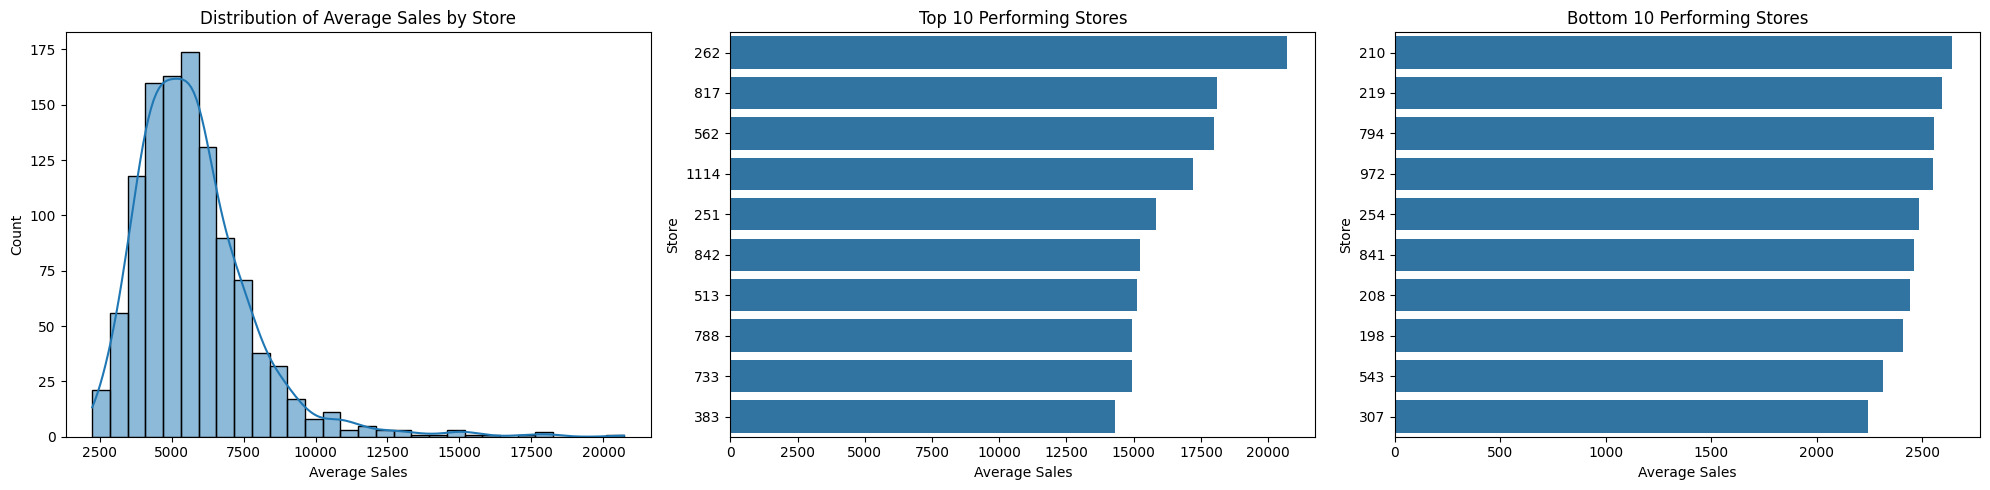

In [29]:
# Average sales by store
store_sales = (
    train_merged
    .groupby("Store")["Sales"]
    .mean()
    .sort_values(ascending=False)
)

top_stores = store_sales.head(10)
bottom_stores = store_sales.tail(10)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Sales by Store
sns.histplot(
    store_sales,
    bins=30,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Distribution of Average Sales by Store")
axes[0].set_xlabel("Average Sales")

# Top 10 Stores
sns.barplot(
    x=top_stores.values,
    y=top_stores.index.astype(str),
    ax=axes[1]
)
axes[1].set_title("Top 10 Performing Stores")
axes[1].set_xlabel("Average Sales")
axes[1].set_ylabel("Store")

# Bottom 10 Stores
sns.barplot(
    x=bottom_stores.values,
    y=bottom_stores.index.astype(str),
    ax=axes[2]
)
axes[2].set_title("Bottom 10 Performing Stores")
axes[2].set_xlabel("Average Sales")
axes[2].set_ylabel("Store")

plt.tight_layout()
plt.show()

Observation
* Average sales vary substantially across stores, with most stores generating around 3,000–8,000 average sales.
* A small number of stores achieve much higher average sales, showing a significant performance gap between stores.
* The top-performing stores exceed 14,000 average sales, while the lowest-performing stores are around 2,200–2,600.
* This indicates that store-level characteristics have an important influence on sales performance.

#### Competition Opening / Reopening Analysis
Competition may affect store performance after a nearby competitor becomes operational. For stores with known competition opening information, we compare sales before and after the competitor's opening to understand whether the presence of a competitor is associated with changes in store sales.

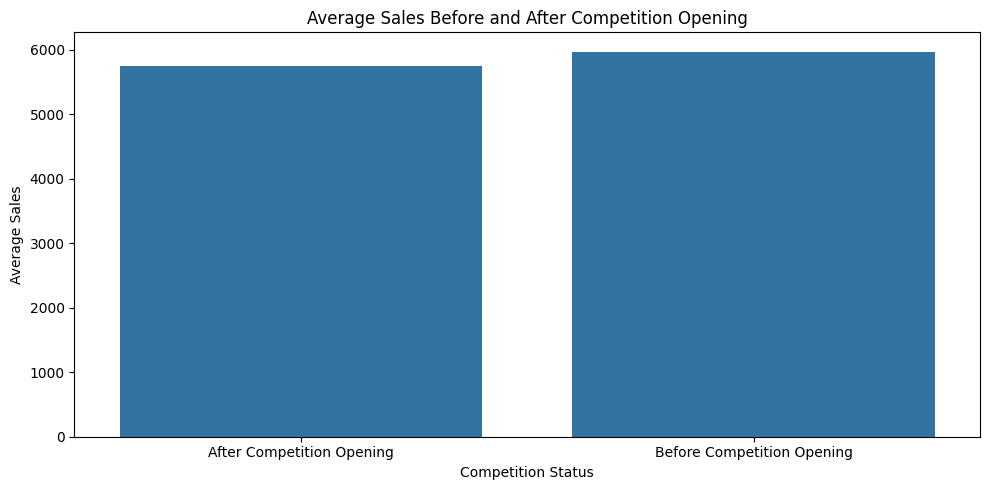

In [30]:
# Create competitor opening date
train_merged["CompetitionOpenDate"] = pd.to_datetime(
    dict(
        year=train_merged["CompetitionOpenSinceYear"],
        month=train_merged["CompetitionOpenSinceMonth"],
        day=1
    ),
    errors="coerce"
)

# Keep stores with known competition opening dates
competition_df = train_merged.dropna(
    subset=["CompetitionOpenDate"]
).copy()

# Compare sales before and after competitor opening
competition_df["CompetitionStatus"] = np.where(
    competition_df["Date"] >= competition_df["CompetitionOpenDate"],
    "After Competition Opening",
    "Before Competition Opening"
)

competition_sales = (
    competition_df
    .groupby("CompetitionStatus")["Sales"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=competition_sales,
    x="CompetitionStatus",
    y="Sales"
)

plt.title("Average Sales Before and After Competition Opening")
plt.xlabel("Competition Status")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

Observation
* Average sales were slightly higher before competition opened (5,950) than after (5,750).
* This suggests a small decline in sales after competitor opening.
* However, this is an association, not proof of causation, as promotions, seasonality, holidays, and store characteristics may also affect sales.

#### Promo2 Analysis
Promo2 is a continuous and recurring promotion available to selected stores. We examine whether stores participating in Promo2 show different sales behaviour compared with stores that do not participate.

2026-09-13 16:23:29,840 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-13 16:23:29,848 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


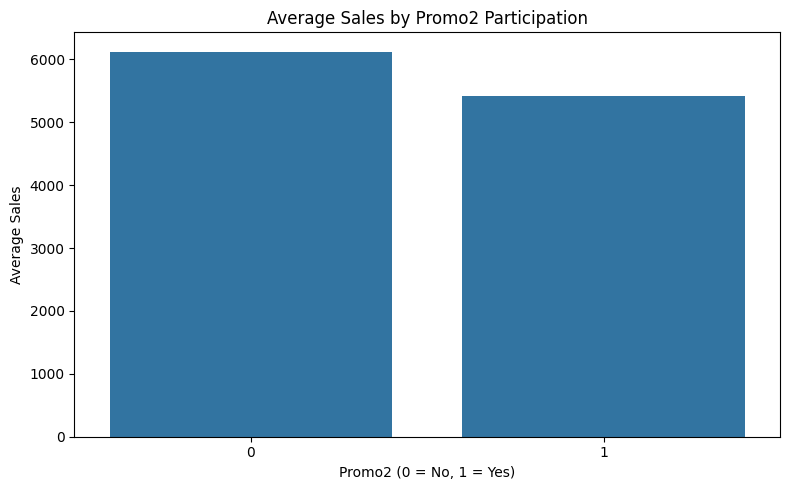

In [31]:
promo2_sales = (
    train_merged
    .groupby("Promo2")["Sales"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=promo2_sales,
    x="Promo2",
    y="Sales"
)

plt.title("Average Sales by Promo2 Participation")
plt.xlabel("Promo2 (0 = No, 1 = Yes)")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

Observation
* Stores without Promo2 show higher average sales (6,100) than stores with Promo2 (5,400).
* This indicates that Promo2 participation is associated with lower average sales in the dataset.
* However, this does not mean Promo2 reduces sales, since Promo2 may be targeted at stores with lower sales.

### Multivariate Analysis
Multivariate analysis examines the combined effect of multiple variables on sales. This helps us move beyond individual relationships and identify whether factors such as promotions, store type, month, weekday, and assortment interact with each other in influencing sales.

#### Sales Across Store Type, Promotion, Month and Weekday

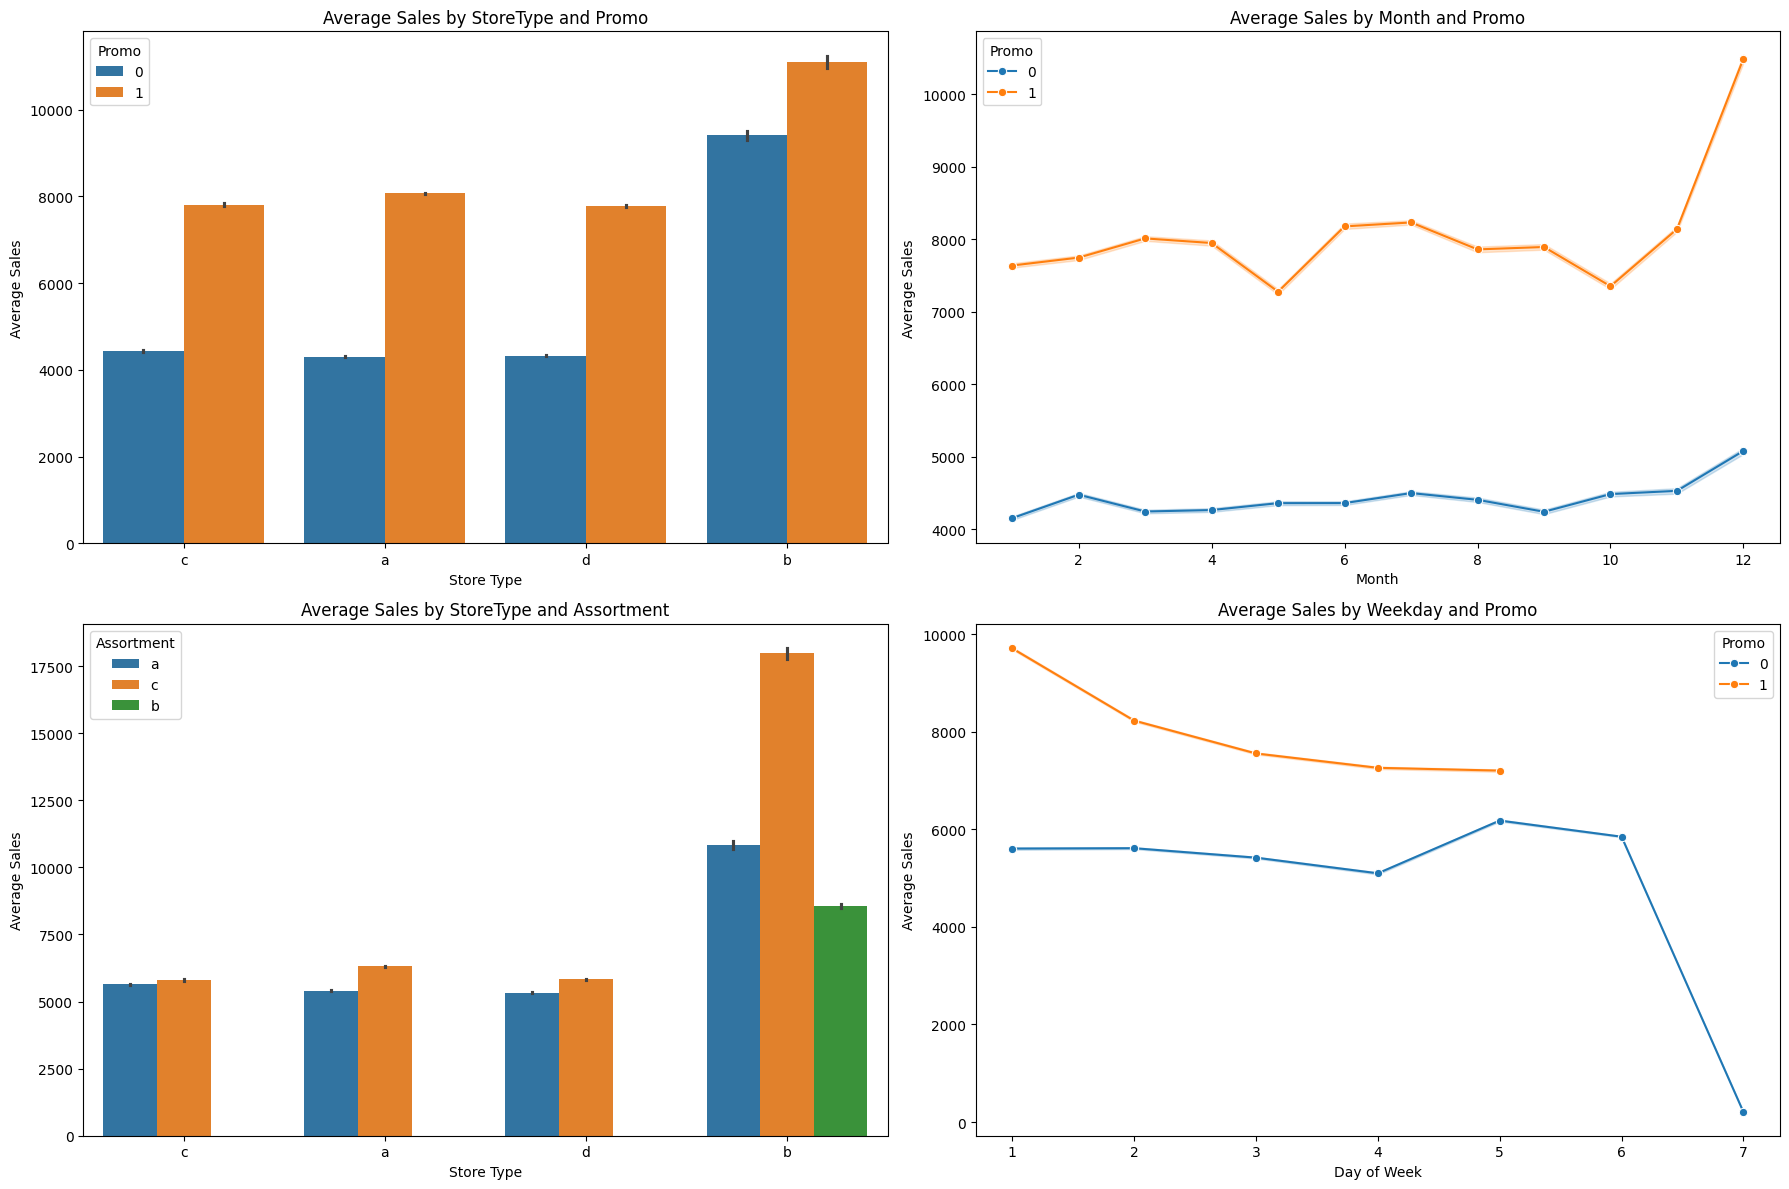

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# StoreType and Promo
sns.barplot(
    data=train_merged,
    x="StoreType",
    y="Sales",
    hue="Promo",
    estimator="mean",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Average Sales by StoreType and Promo")
axes[0, 0].set_xlabel("Store Type")
axes[0, 0].set_ylabel("Average Sales")

# Month and Promo
sns.lineplot(
    data=train_merged,
    x="Month",
    y="Sales",
    hue="Promo",
    estimator="mean",
    marker="o",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Average Sales by Month and Promo")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Average Sales")

# StoreType and Assortment
sns.barplot(
    data=train_merged,
    x="StoreType",
    y="Sales",
    hue="Assortment",
    estimator="mean",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Average Sales by StoreType and Assortment")
axes[1, 0].set_xlabel("Store Type")
axes[1, 0].set_ylabel("Average Sales")

# Weekday and Promo
sns.lineplot(
    data=train_merged,
    x="DayOfWeek",
    y="Sales",
    hue="Promo",
    estimator="mean",
    marker="o",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Average Sales by Weekday and Promo")
axes[1, 1].set_xlabel("Day of Week")
axes[1, 1].set_ylabel("Average Sales")

plt.tight_layout()
plt.show()

Observation
* Promotional periods show higher average sales across store types and weekdays.
* Store Type B records the highest average sales, with particularly high sales for Assortment C.
* Sales vary across months, with promotional sales reaching their highest level toward December.
* Weekday and promotion together influence sales patterns, with promotional days generally showing higher sales and Sunday showing notably lower sales when there is no promotion.
* Overall, the analysis shows that sales are associated with a combination of promotion, store type, assortment, month, and weekday, rather than a single factor.

#### Sales by Store and Month
Sales can vary considerably between stores and across different months. Examining store-level sales across months helps identify whether individual stores maintain consistent performance or show seasonal variations.

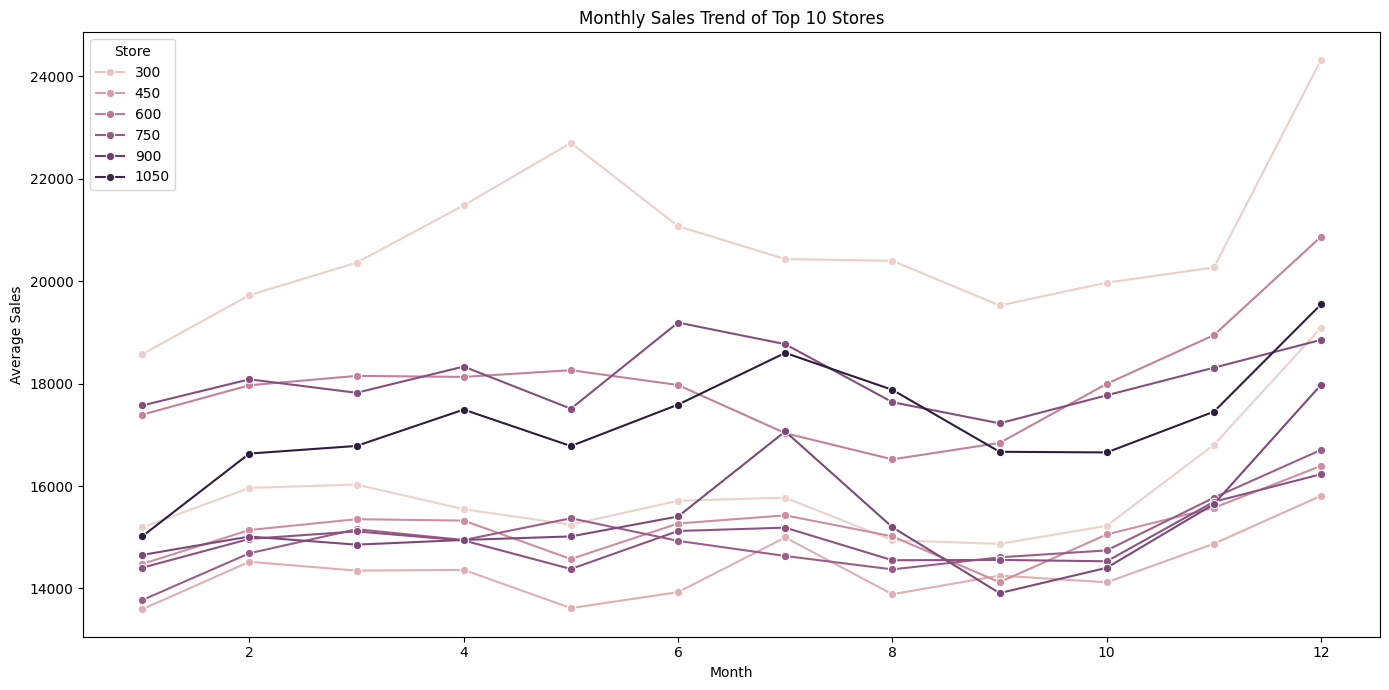

In [33]:
# Average monthly sales by store
store_month_sales = (
    train_merged
    .groupby(["Store", "Month"])["Sales"]
    .mean()
    .reset_index()
)

# Select top 10 stores based on overall average sales
top_10_stores = (
    train_merged
    .groupby("Store")["Sales"]
    .mean()
    .nlargest(10)
    .index
)

plot_data = store_month_sales[
    store_month_sales["Store"].isin(top_10_stores)
]

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=plot_data,
    x="Month",
    y="Sales",
    hue="Store",
    marker="o"
)

plt.title("Monthly Sales Trend of Top 10 Stores")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

Observation
* The top 10 stores show different levels of sales performance, with Store 300 consistently performing the strongest.
* Several top-performing stores show monthly fluctuations, indicating that sales patterns can differ across stores.
* November and December show increased sales for many stores, with December being particularly strong.
* This suggests that store-level performance and seasonal patterns are important factors for sales forecasting.

#### Additional Multivariate Insights
To obtain a broader view of the factors associated with sales, we examine the combined relationship between customers, promotions, store type, and sales. This helps identify patterns that may not be visible when variables are analysed individually.

In [34]:
# Average sales and customers by StoreType and Promo
multivariate_summary = (
    train_merged
    .groupby(["StoreType", "Promo"])
    .agg(
        Average_Sales=("Sales", "mean"),
        Average_Customers=("Customers", "mean")
    )
    .reset_index()
)

display(multivariate_summary)

,StoreType,Promo,Average_Sales,Average_Customers
0,a,0,4300.418175,528.479780
1,a,1,8068.080939,870.600207
2,b,0,9409.434791,1909.851288
3,b,1,11109.739497,2113.734039
4,c,0,4435.040156,558.208497
5,c,1,7810.174738,859.572372
6,d,0,4326.661817,411.065704
7,d,1,7776.593414,648.122890


Observation
* Promotional periods have higher average sales and customer counts across all Store Types.
* Store Type B has the highest sales and customer activity, both with and without promotions.
* The increase in sales during promotion periods is accompanied by higher average customer counts, suggesting that promotions are associated with increased customer activity.
* Overall, Store Type, promotion, and customer activity together show meaningful differences in sales, supporting their inclusion as forecasting features.

### Train vs Test Analysis
Before moving to model building, we compare the train and test datasets to check whether their key feature distributions and store coverage are reasonably consistent. This helps identify potential distribution differences that could affect forecasting performance.

#### Feature, Store, Promotion and Date Comparison

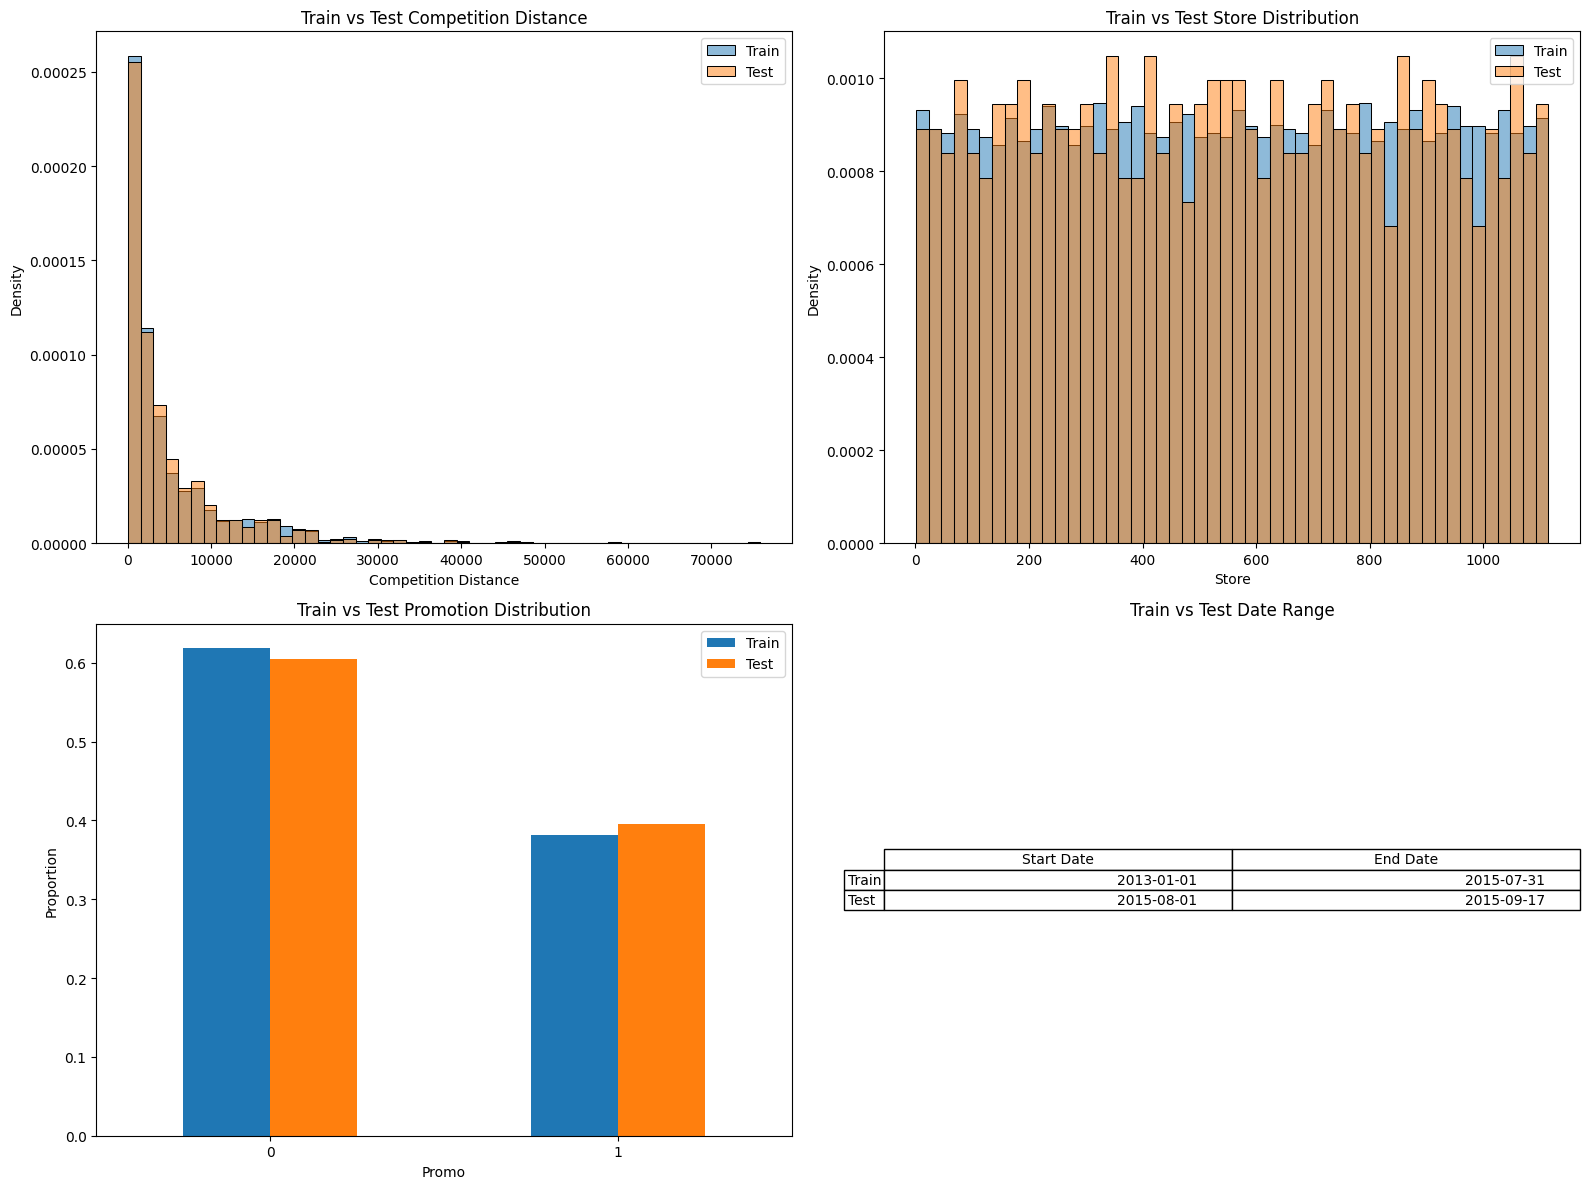

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Feature distribution comparison - Competition Distance
sns.histplot(
    train_merged["CompetitionDistance"].dropna(),
    bins=50,
    stat="density",
    label="Train",
    alpha=0.5,
    ax=axes[0, 0]
)

sns.histplot(
    test_merged["CompetitionDistance"].dropna(),
    bins=50,
    stat="density",
    label="Test",
    alpha=0.5,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Train vs Test Competition Distance")
axes[0, 0].set_xlabel("Competition Distance")
axes[0, 0].legend()

# 2. Store distribution
sns.histplot(
    train_merged["Store"],
    bins=50,
    stat="density",
    label="Train",
    alpha=0.5,
    ax=axes[0, 1]
)

sns.histplot(
    test_merged["Store"],
    bins=50,
    stat="density",
    label="Test",
    alpha=0.5,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Train vs Test Store Distribution")
axes[0, 1].legend()

# 3. Promotion distribution
promo_comparison = pd.DataFrame({
    "Train": train_merged["Promo"].value_counts(normalize=True),
    "Test": test_merged["Promo"].value_counts(normalize=True)
})

promo_comparison.plot(
    kind="bar",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Train vs Test Promotion Distribution")
axes[1, 0].set_xlabel("Promo")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].tick_params(axis="x", rotation=0)

# 4. Date range comparison
date_ranges = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Start Date": [
        train_merged["Date"].min(),
        test_merged["Date"].min()
    ],
    "End Date": [
        train_merged["Date"].max(),
        test_merged["Date"].max()
    ]
})

axes[1, 1].axis("off")
axes[1, 1].table(
    cellText=date_ranges.iloc[:, 1:].astype(str).values,
    rowLabels=date_ranges["Dataset"],
    colLabels=date_ranges.columns[1:],
    loc="center"
)

axes[1, 1].set_title("Train vs Test Date Range")

plt.tight_layout()
plt.show()

Observation
* Competition Distance distributions are broadly similar in train and test, with both showing a right-skewed pattern.
* Store coverage is consistent between the datasets, with no major difference in store representation.
* Promotion distribution is also similar between train and test, suggesting no major distribution difference for Promo.
* The main difference is the date range: train covers 2013-01-01 to 2015-07-31, while test covers 2015-08-01 to 2015-09-17.
* Therefore, the test set represents a future period, confirming that this is a time-based forecasting problem and that time-aware validation should be used during model building.

## Step 8. Correlation Analysis
Correlation analysis helps identify the strength and direction of linear relationships between numerical variables. This provides an overall view of which features may be associated with Sales and can guide feature selection for the forecasting model.

### Correlation Matrix and Heatmap

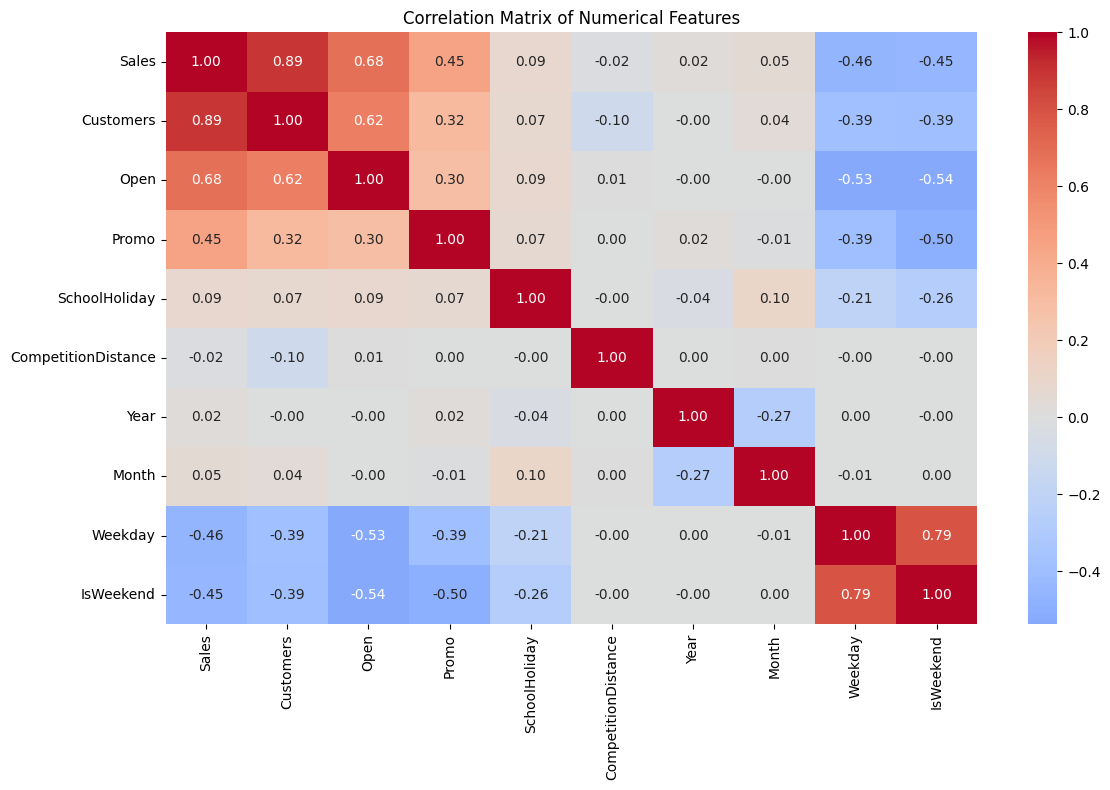

In [36]:
correlation_columns = [
    "Sales",
    "Customers",
    "Open",
    "Promo",
    "SchoolHoliday",
    "CompetitionDistance",
    "Year",
    "Month",
    "Weekday",
    "IsWeekend"
]

correlation_matrix = train_merged[correlation_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

### Correlation with Sales

In [37]:
sales_correlation = (
    correlation_matrix["Sales"]
    .drop("Sales")
    .sort_values(ascending=False)
)

display(
    sales_correlation.to_frame("Correlation with Sales")
)

,Correlation with Sales
Customers,0.894711
Open,0.678472
Promo,0.452345
SchoolHoliday,0.085124
Month,0.048768
Year,0.023519
CompetitionDistance,-0.019229
IsWeekend,-0.450152
Weekday,-0.462125


Observation
* Customers have a very strong positive correlation with Sales (r = 0.89), indicating that higher customer activity is strongly associated with higher sales.
* Open (r = 0.68) and Promo (r = 0.45) also show positive relationships with Sales.
* Weekday and IsWeekend show moderate negative correlations with Sales, indicating differences in sales across the weekly pattern.
* SchoolHoliday (r = 0.09), Month (r = 0.05), Year (r = 0.02), and CompetitionDistance (r = −0.02) show weak or negligible linear relationships with Sales.
* Overall, Customers, Open, Promo, and calendar-related variables show stronger linear associations with Sales, while correlation alone should not be used to remove features.

## Step 9. Key Findings & Business Insights
The EDA has highlighted the major factors and patterns associated with Rossmann store sales. The following findings summarize the most important business insights that can support feature engineering and the development of the sales forecasting model.

Key Findings
* Customer activity is strongly associated with sales, with higher customer counts generally corresponding to higher sales.
* Promotions are associated with higher sales and customer activity, indicating their importance in understanding purchasing behaviour.
* Store operating status is critical, as closed stores generate zero sales.
* Sales vary across weekdays, months, and seasons, with stronger sales generally observed toward the year-end period.
* Store-level performance varies substantially, indicating that store-specific characteristics are important for forecasting.
* Store Type and Assortment contribute to differences in sales, particularly the stronger performance observed for Store Type B.
* Competition distance does not show a clear linear relationship with sales, while competition opening shows a small decline in average sales after opening.
* Promo2 participation is associated with lower average sales, but this does not imply that Promo2 causes lower sales.
* Train and test datasets have broadly similar feature distributions, while the test period represents a future time period, supporting the use of time-aware validation.

## Step 10. Logging

In [38]:
logger.info("EDA completed successfully.")
logger.info("Key business insights identified from sales, customer, promotion, store, competition, and temporal analysis.")

2026-09-13 16:23:56,353 - INFO - EDA completed successfully.
2026-09-13 16:23:56,353 - INFO - Key business insights identified from sales, customer, promotion, store, competition, and temporal analysis.


## Step 11. Conclusion

The exploratory analysis provided a clear understanding of the factors associated with Rossmann store sales. Customer activity, promotions, store operating status, temporal patterns, and store characteristics show important relationships with sales, while competition-related factors show weaker or more complex relationships. The train and test datasets are broadly consistent in their key feature distributions, with the test set representing a future period. These findings provide the foundation for feature engineering, time-aware validation, and machine learning-based sales forecasting.